In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
# 下载 GLD 和 GDX 历史数据
symbols = ["GLD", "GDX"]
data = yf.download(symbols, start="2006-01-01", auto_adjust=True)

[*********************100%***********************]  2 of 2 completed


In [4]:
# 只保留收盘价
prices = data["Close"].dropna()
prices.head()

Ticker,GDX,GLD
Date,,
2006-05-22,31.594475,65.300003
2006-05-23,32.213974,66.379997
2006-05-24,30.991943,64.059998
2006-05-25,32.519470,64.699997
2006-05-26,32.714661,65.099998


In [5]:
# 划分训练集 / 测试集
train_test_split = 252
trainset = prices.iloc[:train_test_split]
testset  = prices.iloc[train_test_split:]
trainset

Ticker,GDX,GLD
Date,,
2006-05-22,31.594475,65.300003
2006-05-23,32.213974,66.379997
2006-05-24,30.991943,64.059998
2006-05-25,32.519470,64.699997
2006-05-26,32.714661,65.099998
...,...,...
2007-05-16,32.716129,65.599998
2007-05-17,32.562923,65.059998
2007-05-18,33.201248,65.519997


In [6]:
# 回归估计对冲比率（Hedge Ratio）
X = sm.add_constant(trainset["GDX"])
y = trainset["GLD"]

model = sm.OLS(y, X).fit()
hedge_ratio = model.params["GDX"]
print("Hedge ratio:", hedge_ratio)

Hedge ratio: 1.394516069252464


In [7]:
# 构造 Spread 和 Z-score
prices["spread"] = prices["GLD"] - hedge_ratio * prices["GDX"]

spread_mean = prices["spread"][:train_test_split].mean()
spread_std  = prices["spread"][:train_test_split].std()

prices["zscore"] = (prices["spread"] - spread_mean) / spread_std
prices

Ticker,GDX,GLD,spread,zscore
Date,,,,
2006-05-22,31.594475,65.300003,21.241000,2.372590
2006-05-23,32.213974,66.379997,21.457093,2.497973
2006-05-24,30.991943,64.059998,20.841235,2.140635
2006-05-25,32.519470,64.699997,19.351073,1.276001
2006-05-26,32.714661,65.099998,19.478879,1.350158
...,...,...,...,...
2026-01-06,92.139999,413.179993,284.689283,155.232662
2026-01-07,91.059998,409.230011,282.245381,153.814641
2026-01-08,91.540001,411.489990,283.835988,154.737556


In [8]:
# 交易信号
prices["long"]  = prices["zscore"] <= -2
prices["short"] = prices["zscore"] >=  2
prices["exit"]  = prices["zscore"].abs() <= 1
prices

Ticker,GDX,GLD,spread,zscore,long,short,exit
Date,,,,,,,
2006-05-22,31.594475,65.300003,21.241000,2.372590,False,True,False
2006-05-23,32.213974,66.379997,21.457093,2.497973,False,True,False
2006-05-24,30.991943,64.059998,20.841235,2.140635,False,True,False
2006-05-25,32.519470,64.699997,19.351073,1.276001,False,False,False
2006-05-26,32.714661,65.099998,19.478879,1.350158,False,False,False
...,...,...,...,...,...,...,...
2026-01-06,92.139999,413.179993,284.689283,155.232662,False,True,False
2026-01-07,91.059998,409.230011,282.245381,153.814641,False,True,False
2026-01-08,91.540001,411.489990,283.835988,154.737556,False,True,False


In [9]:
# =========================================================
# 构造配对交易持仓（Pair Trading Positions）
# =========================================================
# 定义价差：
#   spread = GLD - hedge_ratio * GDX
#
# 价差的含义：
#   spread ↓（为负且很小）：
#       GLD 相对 GDX 被低估（GLD 更便宜）
#       预期价差向上回归
#       → 买入 GLD，卖出 GDX
#
#   spread ↑（为正且很大）：
#       GLD 相对 GDX 被高估（GLD 更贵）
#       预期价差向下回归
#       → 卖出 GLD，买入 GDX
#
# =========================================================

positions = pd.DataFrame(
    index=prices.index,
    columns=["GLD", "GDX"],
    data=np.nan
)

# ---------- 做空价差（spread 过高） ----------
# GLD 相对 GDX 偏贵：
#   卖出 GLD（-1）
#   买入 GDX（+1）
positions.loc[prices["short"], :] = [-1,  1]

# ---------- 做多价差（spread 过低） ----------
# GLD 相对 GDX 偏便宜：
#   买入 GLD（+1）
#   卖出 GDX（-1）
positions.loc[prices["long"], :] = [ 1, -1]

# ---------- 平仓 ----------
# 价差回到均值附近，不再有统计优势
positions.loc[prices["exit"], :] = [ 0,  0]

# ---------- 持仓延续 ----------
# 如果今天没有新的交易信号：
#   继续持有昨天的仓位
positions = positions.ffill().fillna(0)
positions

,GLD,GDX
Date,,
2006-05-22,-1.0,1.0
2006-05-23,-1.0,1.0
2006-05-24,-1.0,1.0
2006-05-25,-1.0,1.0
2006-05-26,-1.0,1.0
...,...,...
2026-01-06,-1.0,1.0
2026-01-07,-1.0,1.0
2026-01-08,-1.0,1.0


In [10]:
# 计算日收益率（GLD 和 GDX）
returns = prices[["GLD", "GDX"]].pct_change()
returns

Ticker,GLD,GDX
Date,,
2006-05-22,NaN,NaN
2006-05-23,0.016539,0.019608
2006-05-24,-0.034950,-0.037935
2006-05-25,0.009991,0.049288
2006-05-26,0.006182,0.006002
...,...,...
2026-01-06,0.010813,0.041719
2026-01-07,-0.009560,-0.011721
2026-01-08,0.005523,0.005271


In [11]:
# 使用前一日持仓计算当日 PnL（避免前视偏差）
pnl = (positions.shift(1) * returns).sum(axis=1)
pnl

Date
2006-05-22    0.000000
2006-05-23    0.003069
2006-05-24   -0.002985
2006-05-25    0.039297
2006-05-26   -0.000180
                ...   
2026-01-06    0.030905
2026-01-07   -0.002161
2026-01-08   -0.000251
2026-01-09    0.003901
2026-01-12    0.015417
Length: 4942, dtype: float64

In [12]:
sharpe_train = np.sqrt(train_test_split) * pnl.iloc[1:train_test_split].mean() / pnl.iloc[1:train_test_split].std()
print("Sharpe (train):", sharpe_train)

Sharpe (train): 1.9699819342761609


In [13]:
sharpe_test = np.sqrt(train_test_split) * pnl.iloc[train_test_split:].mean() / pnl.iloc[train_test_split:].std()
print("Sharpe (test):", sharpe_test)

Sharpe (test): 0.09971562171430441


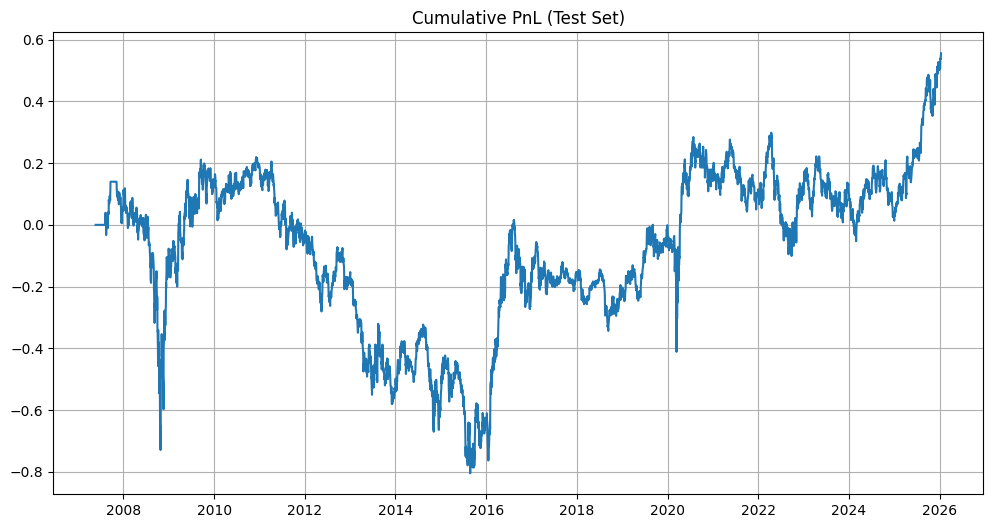

In [17]:
plt.figure(figsize=(12,6))
plt.plot(pnl.iloc[train_test_split:].cumsum())
plt.title("Cumulative PnL (Test Set)")
plt.grid(True)
plt.show()

In [20]:
# 把上面的代码封装成函数
def run_strategy(prices, train_len=252):
    train = prices.iloc[:train_len]

    X = sm.add_constant(train["GDX"])
    y = train["GLD"]
    hedge_ratio = sm.OLS(y, X).fit().params["GDX"]

    spread = prices["GLD"] - hedge_ratio * prices["GDX"]
    spread_mean = spread.iloc[:train_len].mean()
    spread_std  = spread.iloc[:train_len].std()
    zscore = (spread - spread_mean) / spread_std

    longs  = zscore <= -2
    shorts = zscore >=  2
    exits  = zscore.abs() <= 1

    positions = pd.DataFrame(0, index=prices.index, columns=["GLD", "GDX"])
    positions[shorts] = [-1,  1]
    positions[longs]  = [ 1, -1]
    positions[exits]  = [ 0,  0]

    positions = positions.replace(0, np.nan).ffill().fillna(0)
    return positions


In [21]:
positions_full = run_strategy(prices)


In [22]:
cutoff = 60
prices_cut = prices.iloc[:-cutoff]

positions_cut = run_strategy(prices_cut)


In [23]:
common_index = positions_cut.index

if not positions_full.loc[common_index].equals(positions_cut):
    print("Program has look-ahead bias!")
else:
    print("No look-ahead bias detected.")


No look-ahead bias detected.
